# Using the `Kernel` Class

The `Kernel` class lies at the heart of the ASD pipeline. This class computes the kernel function, $\Phi(a, r)$, given the eccentricity profile. This section is structured around three distinct modes of operation, depending on the type of eccentricity distribution used:

- Using a unique eccentricity profile (via `UniqueEccentricity`)
- Using a built-in eccentricity distribution (e.g. `RayelighEccentricity`)
- Using a custom eccentricity profile.

There is a single `Kernel` class for all eccentricity types, with the class detecting and handling each case automatically. 

The first two types have known, analytic kernels, meaning the package doesn't need to numerically integrate the eccentricity profile.

## Kernel for a Unique Eccentricity Profile

When the eccentricity profile is unique, i.e. $e = e(a)$, the kernel $\Phi_e(r, a)$ can be computed analytically without any need for numerical integration:

$$
\Phi_e(r, a) = 
\begin{cases}
\displaystyle \frac{1}{\sqrt{e^2(a) - \kappa^2(r, a)}} & \text{if } e(a) > \kappa(r, a) \\
0 & \text{otherwise}
\end{cases}
$$

where $\kappa(r, a) = |1 - r/a|$.  
The function $\Phi_e(r, a)$ is only defined when the condition $e(a) > \kappa(r, a)$ is satisfied.

Because the expression is fully analytic, the kernel is stored in functional form — no grid construction or interpolation is performed in this mode.

### Initialising and Computing the Kernel

To initialise the kernel, simply call `Kernel(...)` and pass in the previously initialised eccentricity class via the `eccentricity_profile` keyword.

You must also specify `r_min` and `r_max`, which define the radial domain over which the kernel will be evaluated. This domain also determines the range used in future surface density calculations and visualisation plots.

Once the class is created, the **kernel must be computed and saved internally** by calling the `.compute()` method. This step is mandatory before the kernel can be used in downstream calculations.

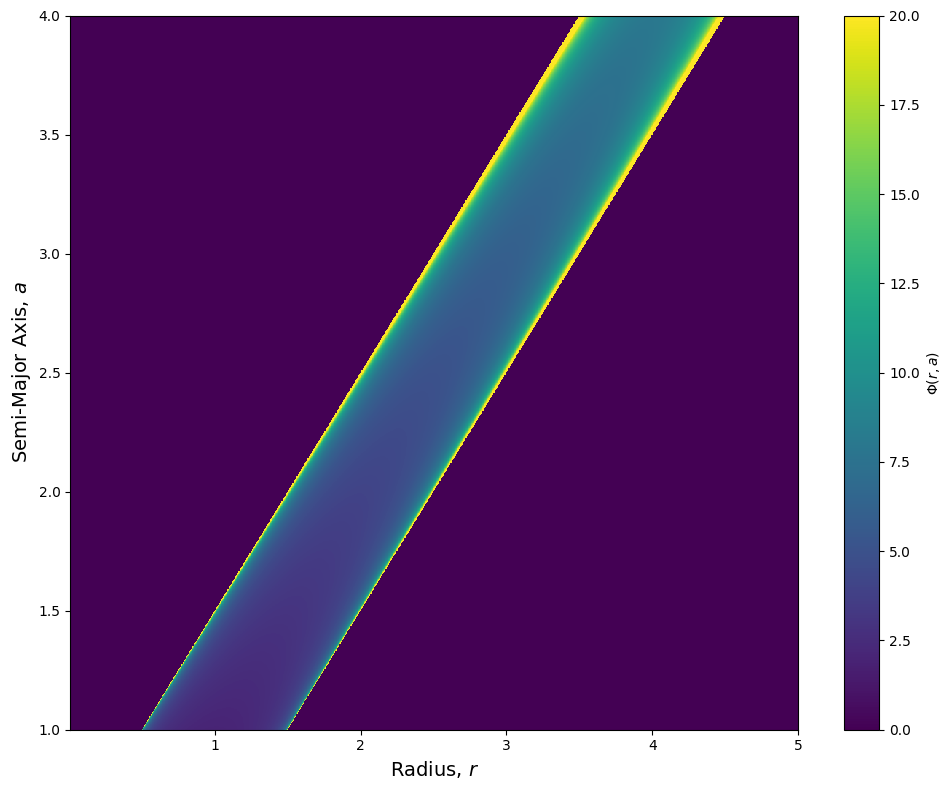

In [1]:
from debrispy import UniqueEccentricity, Kernel

unique_ecc = UniqueEccentricity(a_min = 1, a_max = 4, e0 = 0.5, power = 1)

kernel = Kernel(eccentricity_profile=unique_ecc, 
                r_min = 0.01, r_max = 5,
                num_a_points = 1000, num_r_points = 1000)
kernel.compute()

kernel.plot(vmin = 0, vmax = 20)

### Visualising the Kernel Gradient

An additional feature available specifically for unique eccentricity profiles is the ability to visualise the **gradient of the kernel**. While not required in the main modelling pipeline, this diagnostic can provide valuable insights into the behaviour of $\Phi(r, a)$, particularly the presence of sharp or discontinuous features. 

First, the user must calculate the gradients using the `compute_grad()` method, this computes:

- $\partial \Phi / \partial a$: the derivative along the semi-major axis direction  
- $\partial \Phi / \partial r$: the derivative along the radial direction  
- $|\nabla \Phi|$: the magnitude of the full gradient


Next, the user can visualise using the `plot_grad()` method. The method supports several optional arguments:

- `vmin`, `vmax`: to fix the colour scale across plots  
- `r_lim`, `a_lim`: to restrict the plotting region in $r$ and $a$  
- `cmap`: matplotlib colormap (default: `'viridis'`)  
- `save=True`: to save the plot instead of displaying it  
- `filename='...'`: filename to save to (required if `save=True`)


This is useful for identifying regions where special care may be needed, such as when modelling eccentricities with abrupt transitions or step-like features.

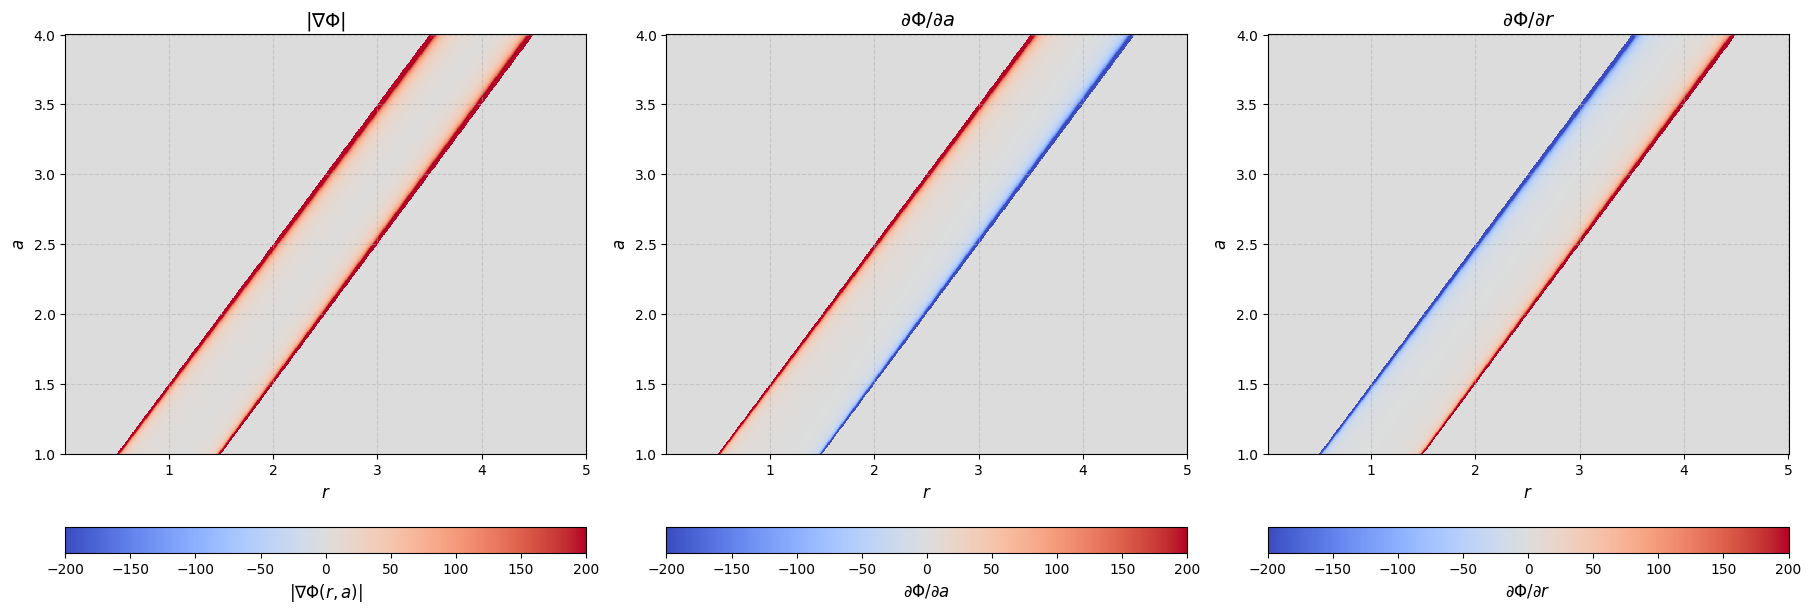

In [2]:
kernel.compute_grad()
kernel.plot_grad(type = 'all', vmin =-200, vmax = 200, cmap = 'coolwarm')

## Kernel for a Built-In Eccentricity Distribution

The built-in eccentricity profiles have known analytic kernel forms. This means that the package does **not** need to perform numerical integration over the eccentricity distribution.

Since these analytic forms are available, the `Kernel` class also avoids any gridding or interpolation steps for $\Phi$. Instead, it directly evaluates the kernel at the requested $(r, a)$ values using the closed-form expressions.


### Rayleigh Distribution

The kernel for the Rayleigh distribution is defined as:

$$
\Phi_e(r, a) = 
\left( \frac{\pi}{2} \right)^{1/2} 
\frac{e^{-\kappa^2 / 2\sigma^2}}{\sigma \left(1 - e^{-1 / 2\sigma^2} \right)} 
\, \text{erf} \left( \sqrt{ \frac{1 - \kappa^2}{2\sigma^2} } \right),
$$

where $\sigma$ is the Rayleigh width parameter.

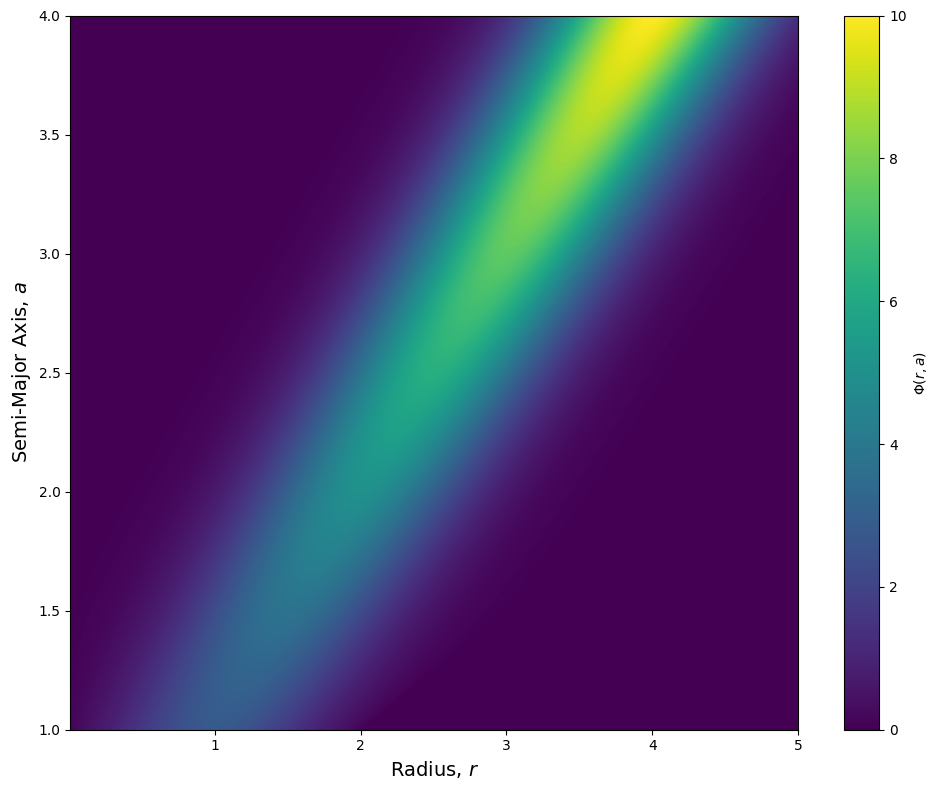

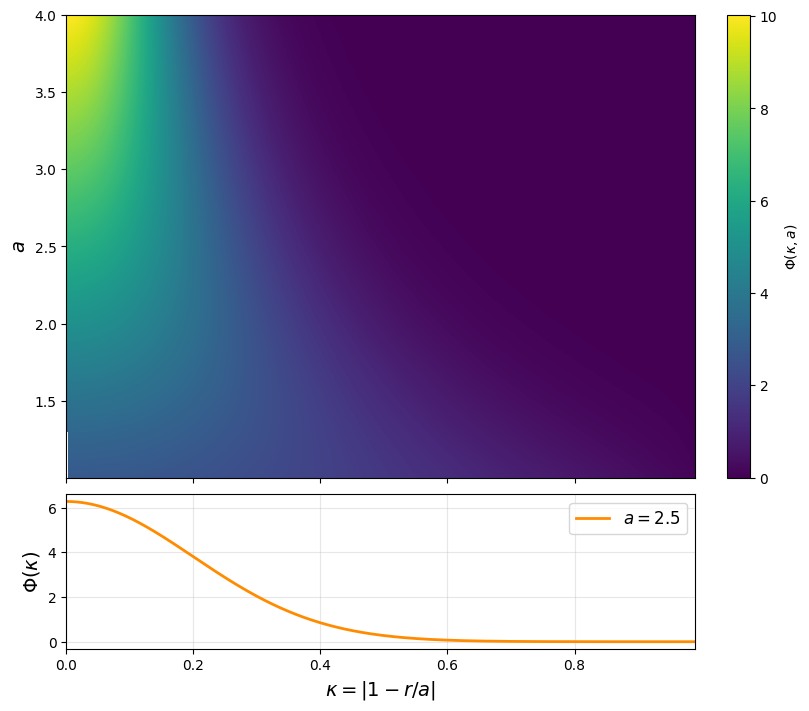

In [3]:
from debrispy import RayleighEccentricity

ray_ecc = RayleighEccentricity(a_min=1, a_max=4, sigma0=0.5, power=1)

kernel = Kernel(eccentricity_profile=ray_ecc, 
                r_min = 0.01, r_max = 5,
                num_a_points = 1000, num_r_points = 1000)
kernel.compute()

kernel.plot(vmin = 0, vmax = 10)
kernel.plot_phi_kappa()

### Optional Approximation for Rayleigh Distribution

In addition to the full expression for the Rayleigh distribution kernel, we also include the approximate form of the kernel at the **small eccentricity limit**, which is controlled by the `rayleigh_approx` flag in the `compute()` method.

If `rayleigh_approx=True`, the following closed-form expression is used instead:

$$
\Phi(r, a) = \sqrt{\frac{\pi}{2}} \cdot \frac{1}{\sigma} \cdot \exp\left(-\frac{\kappa^2}{2\sigma^2}\right).
$$

This approximation assumes small eccentricities, i.e., $e \ll 1$, which corresponds to $\sigma(a) \ll 1$. It is accurate in the low-eccentricity regime.

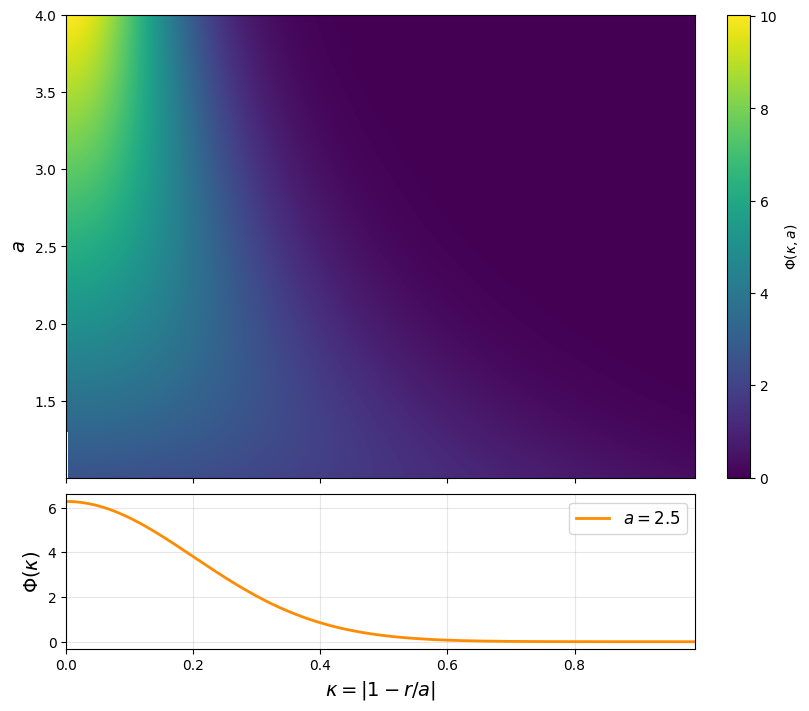

In [4]:
ray_ecc = RayleighEccentricity(a_min=1, a_max=4, sigma0=0.5, power=1)

kernel = Kernel(eccentricity_profile=ray_ecc, 
                r_min = 0.01, r_max = 5,
                num_a_points = 1000, num_r_points = 1000)
kernel.compute(rayleigh_approx=True)

kernel.plot_phi_kappa()

### "Top-Hat" Kernel

For the top-hat eccentricity distribution, the kernel is defined as:

$$
\Phi_e(\kappa) = 
\begin{cases}
\left( \frac{\pi}{2} \right) \lambda^{-1}, & \kappa \leq \lambda, \\
0, & \kappa > \lambda,
\end{cases}
$$

where $\lambda$ is the width of the top-hat in eccentricity space.

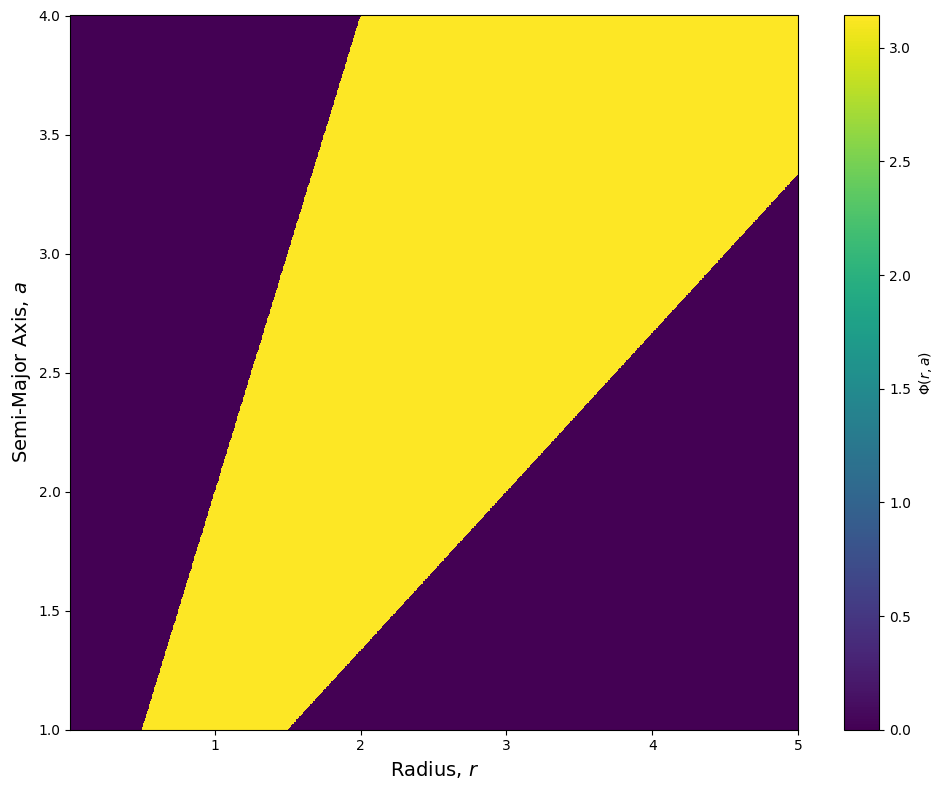

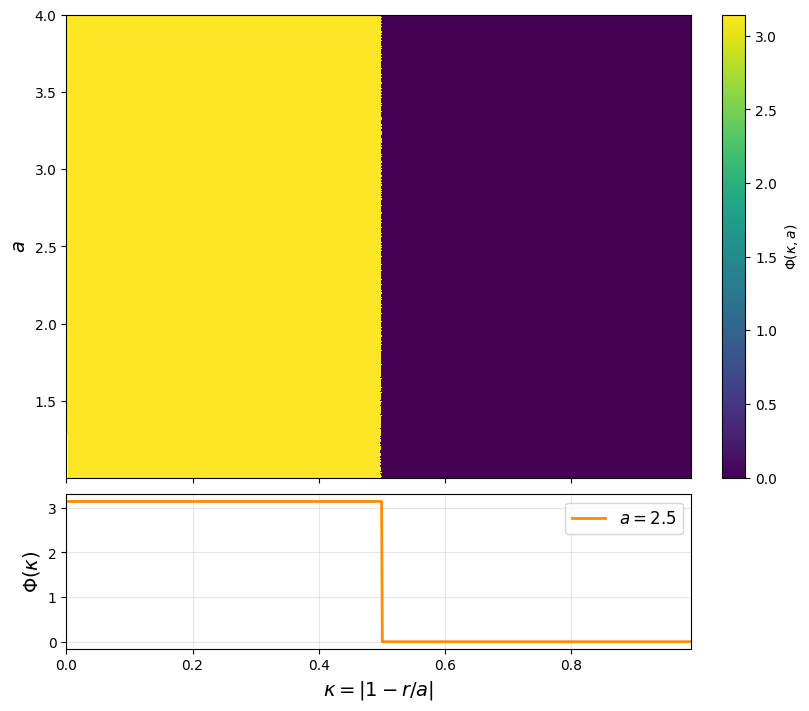

In [5]:
from debrispy import TopHatEccentricity

tophat_ecc = TopHatEccentricity(a_min=1, a_max=4, lam=0.5)

kernel = Kernel(eccentricity_profile=tophat_ecc, 
                r_min = 0.01, r_max = 5,
                num_a_points = 1000, num_r_points = 1000)
kernel.compute()

# Plot the kernel
kernel.plot()

# Plot the kernel in terms of a v.s. kappa
kernel.plot_phi_kappa()

### "Triangular" Kernel

For the triangular eccentricity distribution, the kernel is given by:

$$
\Phi_e(\kappa) = 
\begin{cases}
\pi \lambda^{-2} (\lambda - \kappa), & \kappa \leq \lambda, \\
0, & \kappa > \lambda,
\end{cases}
$$

where $\lambda$ is the maximum eccentricity value supported by the distribution.

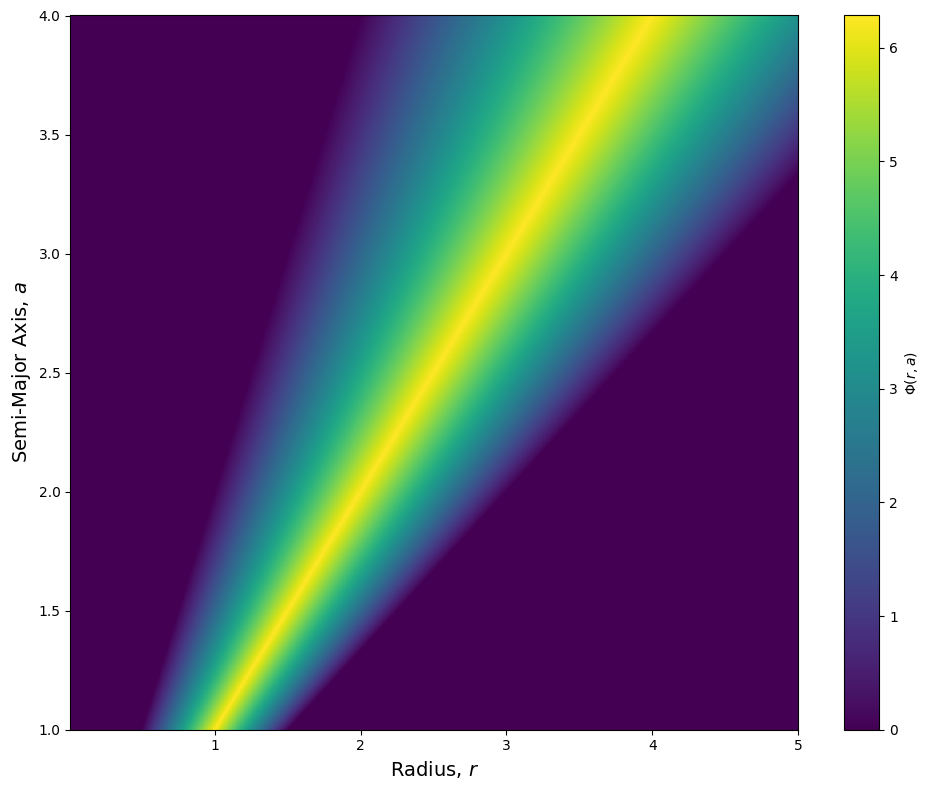

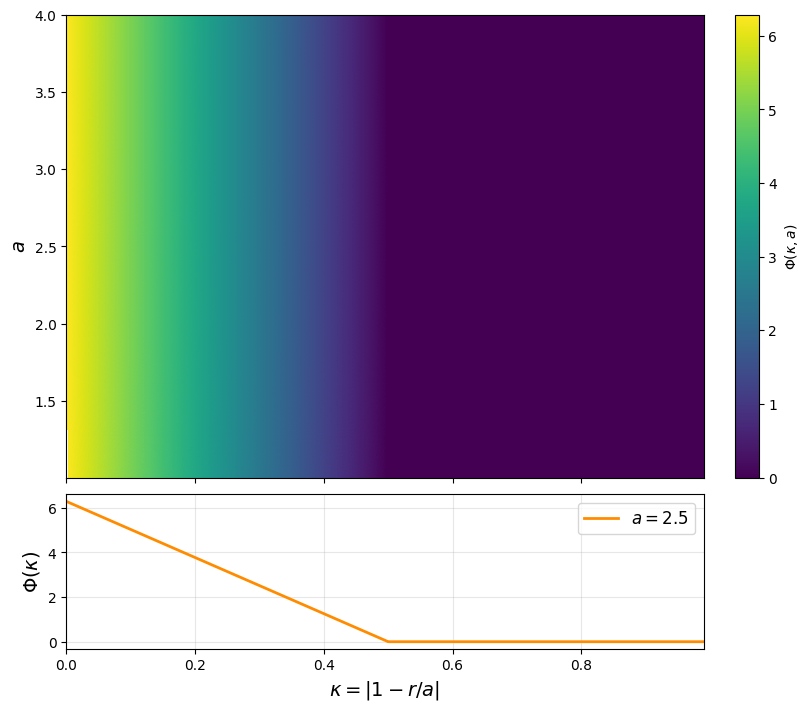

In [6]:
from debrispy import TriangularEccentricity

tri_ecc = TriangularEccentricity(a_min=1, a_max=4, lam=0.5)

kernel = Kernel(eccentricity_profile=tri_ecc, 
                r_min = 0.01, r_max = 5,
                num_a_points = 1000, num_r_points = 1000)
kernel.compute()

kernel.plot()
kernel.plot_phi_kappa()

### "Power-Law" Kernel

For the power-law eccentricity distribution, the kernel is defined as:

$$
\Phi_e(\kappa) = 
\begin{cases}
\pi^{1/2} \lambda^{-(2\zeta + 1)} \dfrac{\Gamma(\zeta + 3/2)}{\Gamma(\zeta + 1)} \left( \lambda^2 - \kappa^2 \right)^\zeta, & \kappa \leq \lambda \\
0, & \kappa > \lambda
\end{cases}
$$

where $\lambda$ is the maximum eccentricity, and $\zeta > 0$ is the power-law index.

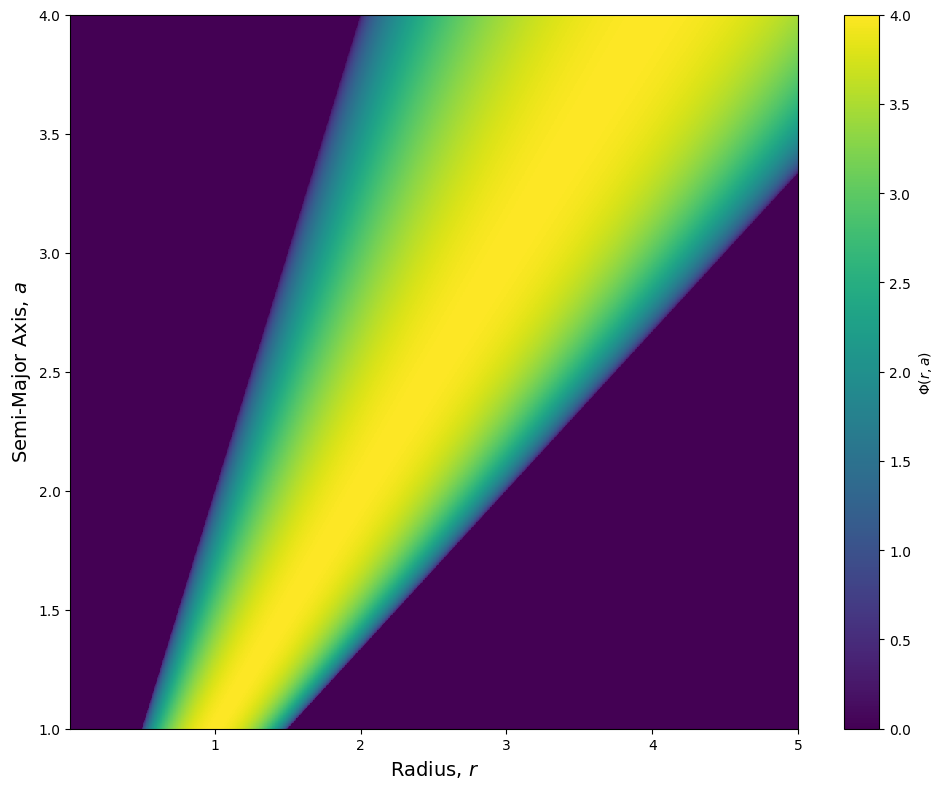

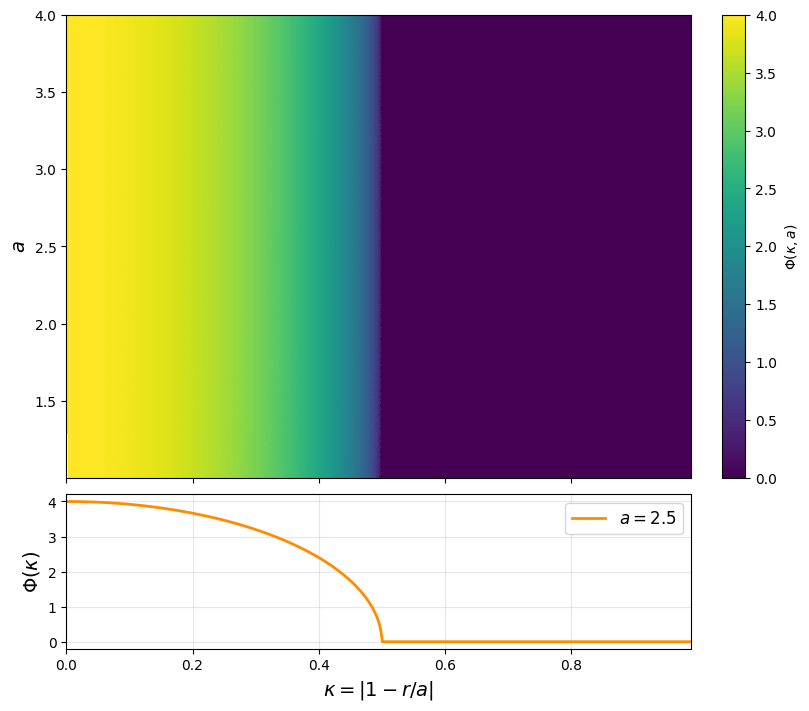

In [7]:
from debrispy import PowerLawEccentricity

power_ecc = PowerLawEccentricity(a_min=1, a_max=4, lam=0.5, zeta = 0.5)

kernel = Kernel(eccentricity_profile=power_ecc, 
                r_min = 0.01, r_max = 5,
                num_a_points = 1000, num_r_points = 1000)
kernel.compute()

kernel.plot()
kernel.plot_phi_kappa()

### "Truncated Gaussian" Kernel

For the truncated Gaussian distribution, the kernel is defined as:

$$
\Phi_e(\kappa) = 
\begin{cases}
C \exp\left( -\dfrac{\kappa^2}{2\sigma_\kappa^2} \right), & \kappa \leq \lambda \\
0, & \kappa > \lambda
\end{cases}
$$

where $\sigma_\kappa$ is the dispersion in $\kappa$, and $C$ is the normalisation constant (see eccentricity section for details).

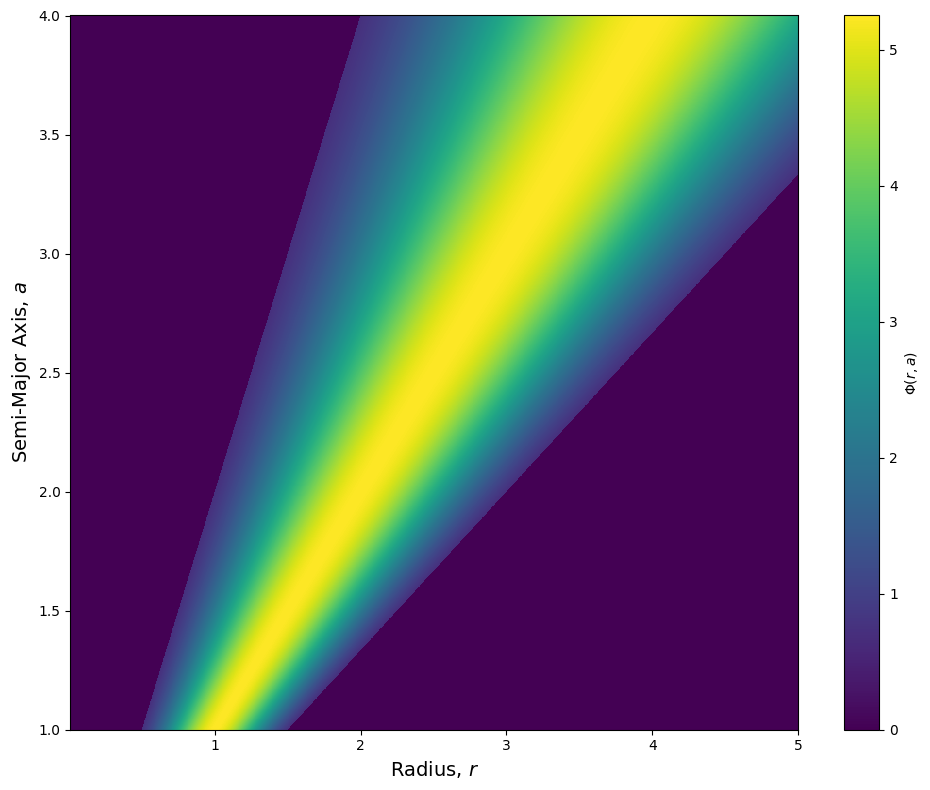

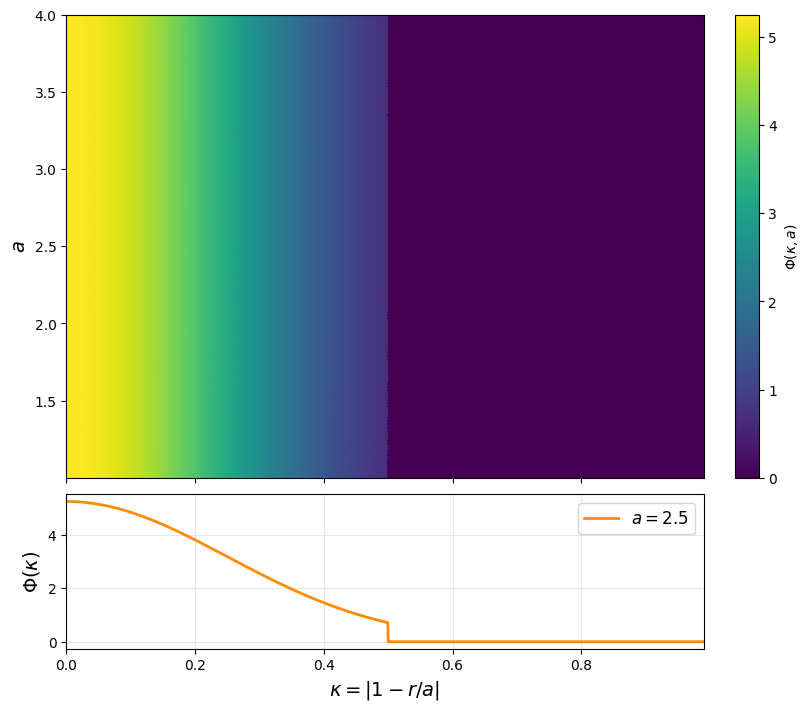

In [8]:
from debrispy import TruncGaussEccentricity

trunc_ecc = TruncGaussEccentricity(a_min=1, a_max=4, lam=0.5, sigma=0.25)

kernel = Kernel(eccentricity_profile=trunc_ecc, 
                r_min = 0.01, r_max = 5,
                num_a_points = 1500, num_r_points = 1500)
kernel.compute()

kernel.plot()
kernel.plot_phi_kappa()

## Kernel for a General (User-Supplied) Eccentricity Distribution

For user-supplied eccentricity distributions, an analytic form for the kernel, $\Phi(r, a)$ is generally not available. Instead, the kernel must be computed numerically via integration for every $r$-$a$ pair using, 

$$
\Phi_e(r, a) = \int_\kappa^{1} \frac{\psi_e(e, a)}{\sqrt{e^2 - \kappa^2}} de
$$

where $\kappa = |1 - r/a|$ and $\psi_e(e, a)$ is the eccentricity distribution provided by the user.

Since this computation is required for each pair of $r$ and $a$, and each evaluation involves an integral, this can become computationally expensive. Therefore, the kernel class provides a suite of efficient and flexible integration techniques as well as optional adaptive gridding to manage performance and accuracy.

### Integration Methods

Three integration methods are available via the `method` keyword in `compute()`:

- `'trapz'`: Trapezium rule using NumPy (simplest and fastest but not precise)

- `'gauss'`: Gauss–Legendre quadrature (recommended for speed and precision, requires some tuning)

- `'quad'`: Adaptive integration using SciPy’s `quad()` (precise with less tuning, very slow)

In all three cases, when using uniform gridding, the integration is parallelised over each $a$ row using `joblib`, with the number of 'jobs' set via the `n_jobs` keyword argument. This significantly reduces the compute time.

### Integration via Trapezium Rule (Quick / Not Accurate)

The trapezium rule provides the fastest but least accurate method for computing the kernel. It is intended primarily for quick checks or testing small parameter spaces.

This method has strict requirements:

- The eccentricity distribution must be sampled on a uniform grid in both $e$ and $a$.
- The semi-major axis grid used to define $\psi_e(e, a)$ must exactly match the kernel's internal `a_grid` — including range and number of points.

Because it lacks adaptivity or error control, this method may introduce strong aliasing or numerical instability, particularly when the integrand varies rapidly.

It supports the keyword argument `eps`, which is a small float used to regularise the integrand near the singularity at $e = \kappa$. This defaults to 1e-5.

Use this method only when performance is more important than precision, or to validate pipeline structure before switching to more robust methods.

An example is given below (and then re-calculated using other methods later), it can be seen that the trapezium method, although fast, is innacurate.


Computing Φ(r,a) using Trapezium Rule: 100%|██████████| 500/500 [00:01<00:00, 304.50it/s]


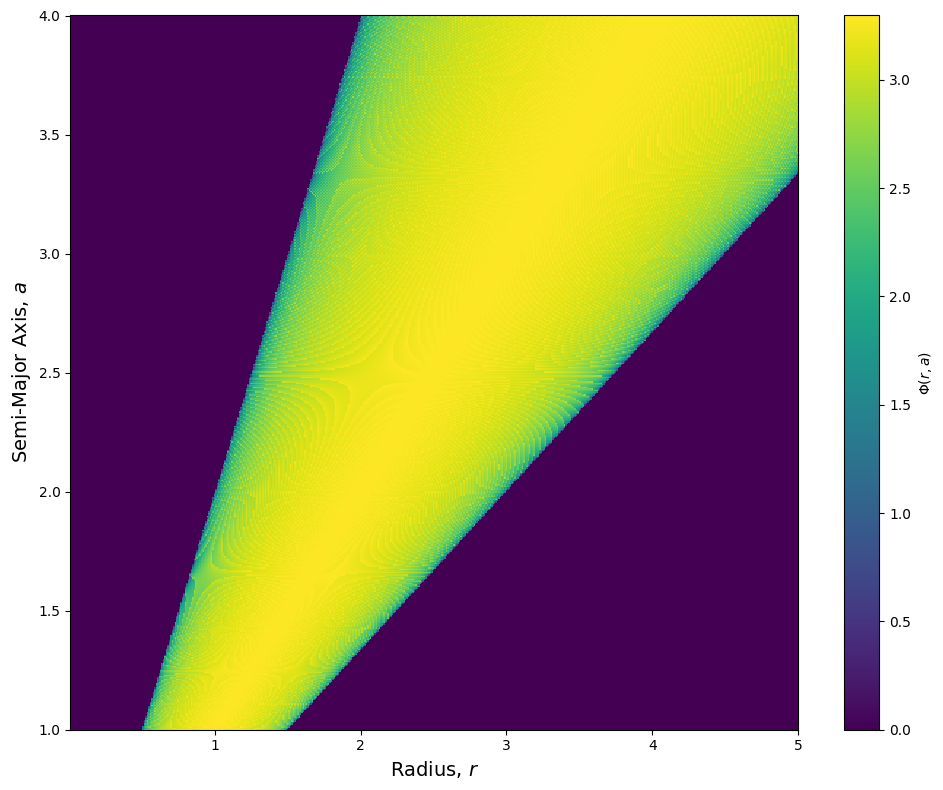

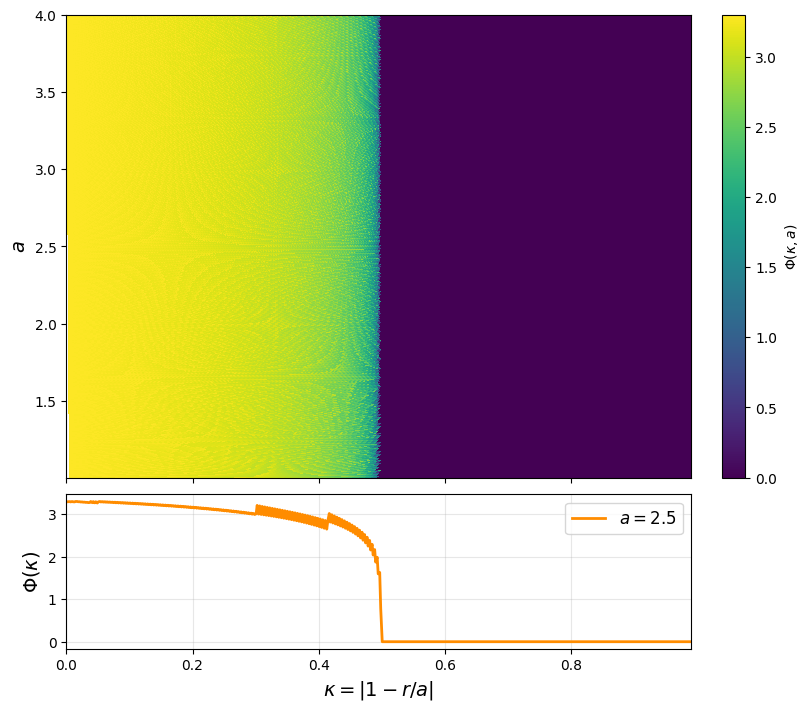

In [9]:
import numpy as np
from debrispy import EccentricityDistribution

def lambda_func(a, lambda0 = 0.5, a_min=1, beta = 0):
    return lambda0*(a_min/a)**beta

def psi_powerlaw(e, a, zeta = 0.1):
    e = np.atleast_1d(e)
    a = np.atleast_1d(a)
    lam = lambda_func(a)
    out = np.zeros_like(e)

    mask = (e > 0) & (e < lam)
    lam_mask = lam[mask]
    e_mask = e[mask]

    prefactor = (2 * zeta + 1) / lam_mask**(2 * zeta + 1)
    out[mask] = prefactor * e_mask * (lam_mask**2 - e_mask**2)**(zeta - 0.5)
    return out

ecc_general = EccentricityDistribution(
    a_min=1, 
    a_max=4, 
    distribution_func=lambda e, a: psi_powerlaw(e, a), 
    auto_normalise=True, 
    num_e_points=500, 
    num_a_points=500, 
    grid_type = 'uniform', 
    interpolation_method='linear'
)

kernel = Kernel(eccentricity_profile=ecc_general, 
                r_min = 0.01, r_max = 5,
                num_a_points = 500, num_r_points = 500)


kernel.compute(method='trapz', eps = 1e-4)

# Inaccurate!
kernel.plot()
kernel.plot_phi_kappa()

### Integration via Gauss–Legendre Quadrature (Recommended)

This method uses **Gauss–Legendre quadrature**, offering a balance between **speed and precision**, and is the **recommended integration method** for most use cases.

It supports two modes:

- **Fixed-order quadrature** (fast, efficient for smooth integrands)
- **Adaptive quadrature** (slower, but more accurate near singularities or sharp features)

#### Basic Usage

At minimum, the user must specify:

- `n_points`: Number of quadrature points per subinterval (e.g., 64)
- `eps`: Regularisation parameter to ensure numerical stability near $e = \kappa$

#### Controlling the Integration Region

In some cases, the user may wish to guide the quadrature by **splitting the integration domain** at specific locations — for example, near sharp features in $\psi_e(e, a)$.

This can be done via:

- `upper_limit`: A float or callable specifying the upper bound of integration (defaults to $e=1$ if not supplied)
- `split_points`: A list of floats or callables at which to split the domain before applying fixed-order quadrature

This allows for custom treatment of integrands without resorting to full adaptivity.

#### Adaptive Quadrature

If the integrand contains sharp transitions or singularities and their locations are **not known a priori**, the user can activate **adaptive quadrature** using:

- `adaptive_integration=True`: Enables adaptive splitting of the integration region
- `tol`: Target tolerance for the integration error (e.g., `1e-10`)
- `max_level`: Maximum number of subdivisions; acts as a ceiling to prevent infinite refinement

In this mode, the algorithm recursively subdivides the integration interval until the local error estimate falls below `tol`, or `max_level` is reached. This ensures robust handling of difficult features, but comes at a **significant performance cost**, and is only recommended as a final resort.

> For advanced use cases, we refer the reader to the API documentation and source code for a detailed breakdown of the adaptive integration mechanics.

Computing Φ(r,a) [Gauss]: 100%|██████████| 500/500 [00:03<00:00, 144.02it/s]


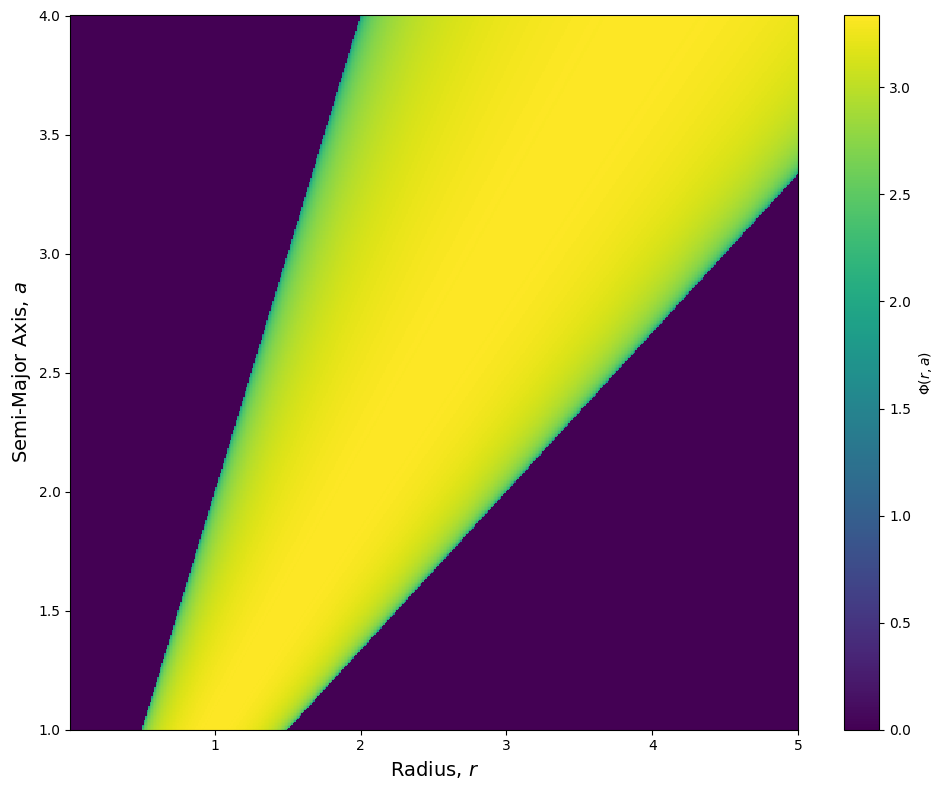

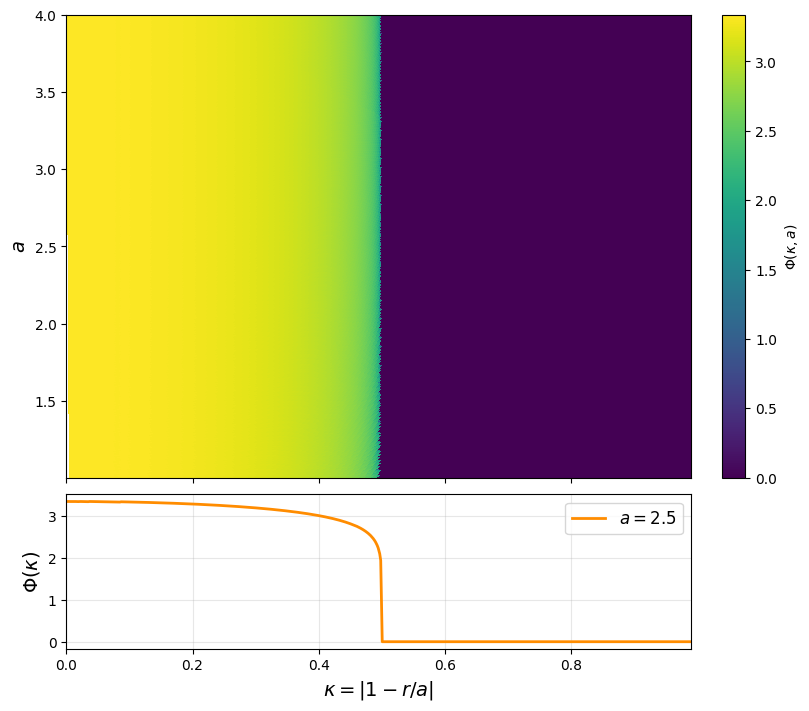

In [10]:
ecc_general = EccentricityDistribution(
    a_min=1, 
    a_max=4, 
    distribution_func=lambda e, a: psi_powerlaw(e, a), 
    auto_normalise=True, 
    num_e_points=500, 
    num_a_points=500, 
    grid_type = 'warped', 
    interpolation_method='linear'
)

kernel = Kernel(eccentricity_profile=ecc_general, 
                r_min = 0.01, r_max = 5,
                num_a_points = 500, num_r_points = 500)


kernel.compute(method='gauss', n_points=256, eps=1e-5, adaptive_integration=False, upper_limit=lambda_func)

kernel.plot()
kernel.plot_phi_kappa()

Computing Φ(r,a) [Gauss]: 100%|██████████| 500/500 [00:01<00:00, 377.24it/s]


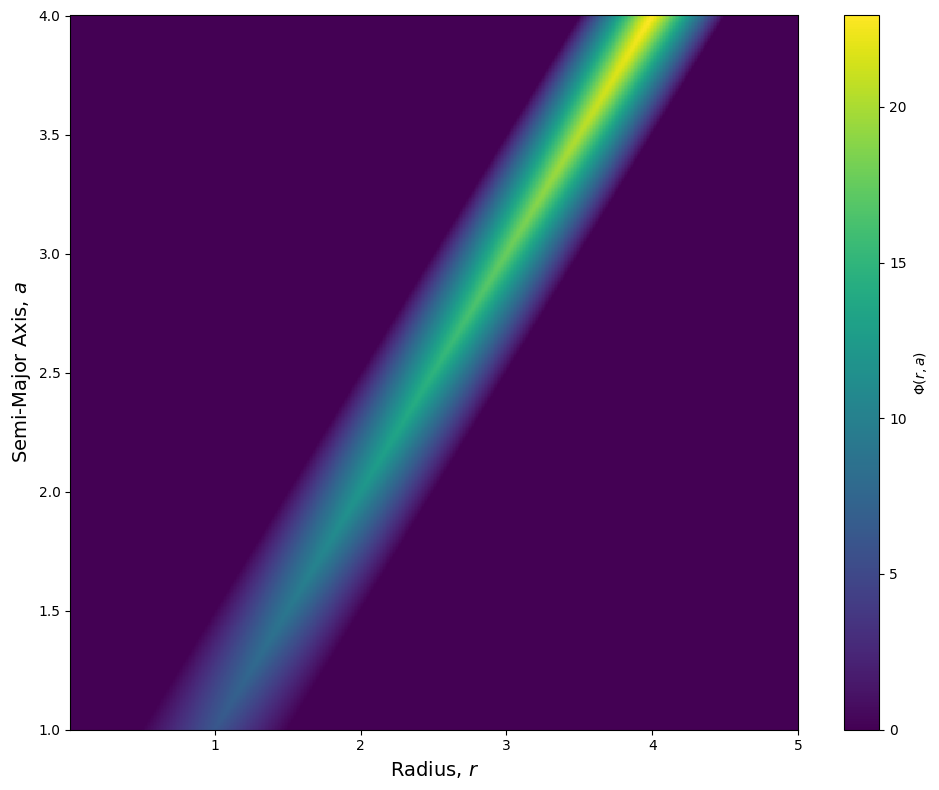

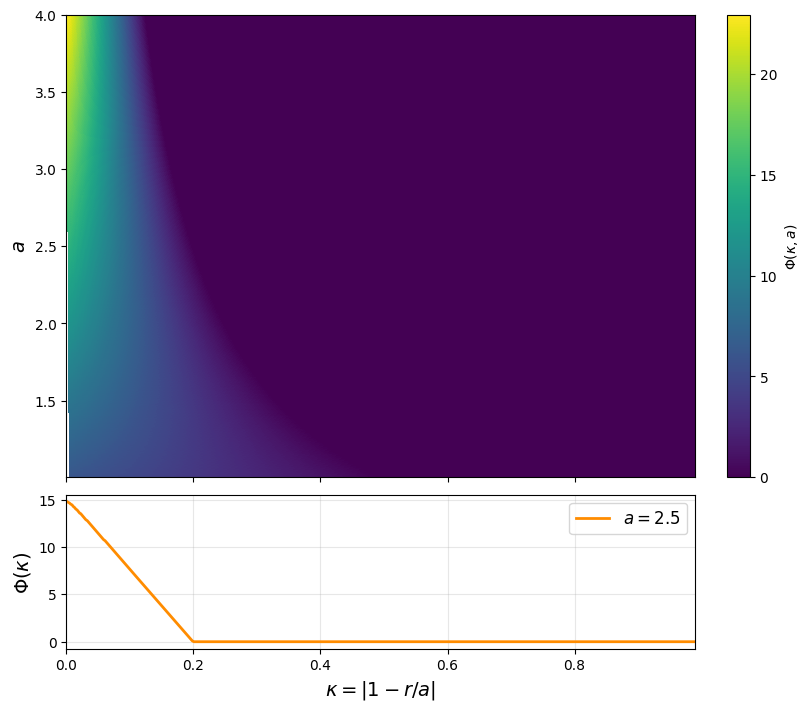

In [11]:
def lambda_func(a, lambda0 = 0.5, a_min=1, beta = 1):
    return lambda0*(a_min/a)**beta

def tri_ecc(e, a):
    e = np.atleast_1d(e)
    a = np.atleast_1d(a)
    lam = lambda_func(a)

    out = np.zeros_like(e)
    mask = (e > 0) & (e < lam)
    lam_masked = lam[mask]
    e_masked = e[mask]

    numerator = lam_masked + np.sqrt(lam_masked**2 - e_masked**2)
    log_term = np.log(numerator / e_masked)

    out[mask] = (2 * e_masked / lam_masked**2) * log_term
    return out

ecc_general = EccentricityDistribution(
    a_min=1, 
    a_max=4, 
    distribution_func=lambda e, a: tri_ecc(e, a), 
    auto_normalise=True, 
    num_e_points=500, 
    num_a_points=500, 
    grid_type = 'adaptive',
    interpolation_method='linear'
)

kernel = Kernel(eccentricity_profile=ecc_general, 
                r_min = 0.01, r_max = 5,
                num_a_points = 500, num_r_points = 500)


kernel.compute(method='gauss', n_points=256, eps=1e-5, adaptive_integration=False, upper_limit=lambda_func)

kernel.plot()
kernel.plot_phi_kappa()

### Integration via SciPy Quad (Slow / Not Recommended)

This method uses **SciPy’s `quad()`** function for adaptive integration. While it is mathematically robust and flexible, it is **very slow** in practice due to the large number of integrations required for the full $\Phi(r, a)$ grid.

We do **not recommend** using this method unless:

- The Gauss–Legendre integration fails for your specific use case
- You are debugging a small portion of the domain and require a high-accuracy baseline

Despite its impracticality for production use, this method is provided for completeness.

#### Parameters

- `eps`: Regularisation parameter (avoids divergence near $e = \kappa$)
- `tol`: Target integration tolerance
- `upper_limit`: Optional float or callable to set the upper limit of integration

This method is compatible with both **uniform and adaptive kernel grids**, though the performance cost remains high in either case.

> Use with caution — this method is primarily intended for fallback or validation purposes.

### Gridding Options

By default, the kernel is evaluated on a **uniform grid**, controlled by the `num_a_points` and `num_r_points` parameters. This grid is structured and easy to visualise, and is used when `adaptive_grid=False`.

Alternatively, the user can enable **adaptive gridding** by setting `adaptive_grid=True`. In this mode, the grid is no longer regular — instead, we use the third-party `adaptive` package to sample $(r, a)$ points in an unstructured way. The resulting kernel is returned as a **scattered set of points**, each carrying a value of $\Phi(r, a)$.

This method does not require you to specify the number of grid points. Instead, you define a **tolerance** `tol` which controls how accurately the space must be sampled. The higher the tolerance, the fewer evaluations are needed.

> This approach can extract more structure using fewer integration calls, especially if $\Phi$ varies sharply in certain regions of the domain.

While adaptive gridding can be slower to initialise, it is often more efficient in terms of the **number of evaluations**. Users are encouraged to experiment with both options to find the most effective setup for their application.


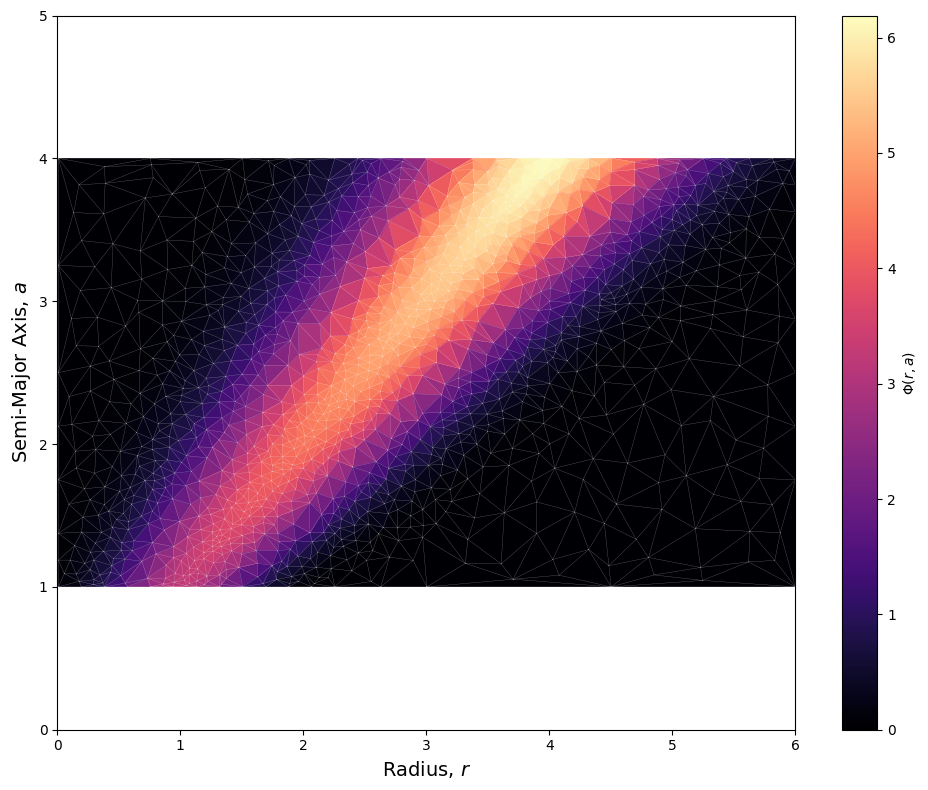

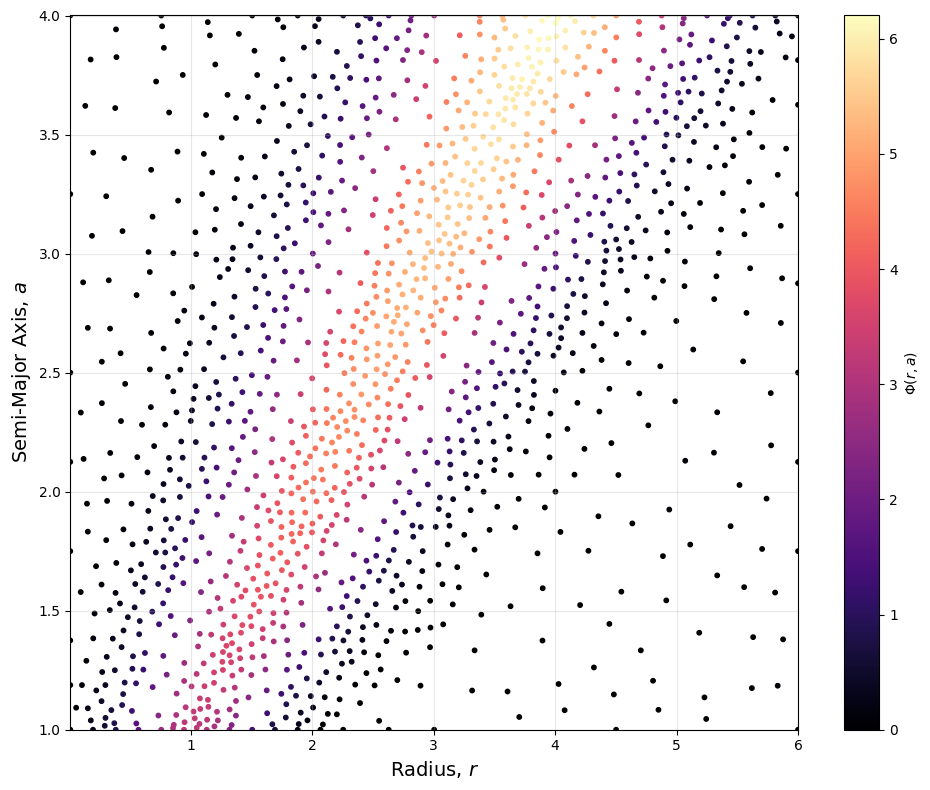

In [12]:
def unnormalised_rayleigh(e, a, sigma0, alpha, a_min):
    sigma = sigma0 * (a_min / a)**alpha
    return (e / sigma**2) * np.exp(-e**2 / (2 * sigma**2))

ecc_general = EccentricityDistribution(
    a_min=1, 
    a_max=4, 
    distribution_func=lambda e, a: unnormalised_rayleigh(e, a, sigma0=0.4, alpha=0.5, a_min=1), 
    auto_normalise=True, 
    num_e_points=500, 
    num_a_points=500, 
    grid_type = 'adaptive', 
    interpolation_method='linear'
)

kernel = Kernel(eccentricity_profile=ecc_general, 
                r_min = 0.01, r_max = 6.0,
                num_a_points = 500, num_r_points = 500)

kernel.compute(method='gauss', n_points=32, adaptive_integration=False, adaptive_grid=True, tol=1e-3, eps = 1e-10)

kernel.plot(edgecolor='white', show_edges=True, r_lim=(0, 6), a_lim=(0, 5), cmap = 'magma')
kernel.plot(points = True, cmap = 'magma')

### Interpolation Options

After gridding, interpolation is used to evaluate $\Phi(r, a)$ at arbitrary points — this is especially important for the subsequent integration step when computing the azimuthally symmetric surface density (ASD).

The user can select one of the following interpolation modes:

- `'nearest'`: Nearest-neighbour interpolation (fast, least smooth)
- `'linear'`: Linear interpolation (**recommended** for most cases)
- `'cubic'`: Cubic interpolation (useful if very few points are available)

The interpolation method is set during initialisation via the `interpolation_method` keyword.

> Note: While interpolation is essential, it should not replace proper sampling. It is **strongly advised** to prioritise generating a well-resolved kernel grid or sample set rather than relying too heavily on interpolation to "fill in the gaps."


## Common Interface for Kernel Class

The `Kernel` class provides a set of utility methods that allow querying, plotting, and analysing the computed kernel values.

### Accessing the Kernel Values 

The kernel values can be accessed via `get_values(a, r)`, which evaluates the kernel at arbitrary points. This method: 

- Returns interpolated kernel values for a general eccentricity distribution.
- Uses direct kernel computation for known analytic forms.

When two arrays are provided, array broadcasting is done automatically for all cases.

In [13]:
# Example 1: Known Analytic Form

unique_ecc = UniqueEccentricity(a_min = 1, a_max = 4, e0 = 0.5, power = 1)

kernel = Kernel(eccentricity_profile=unique_ecc, 
                r_min = 0.01, r_max = 5,
                num_a_points = 1000, num_r_points = 1000)
kernel.compute()

a_values = np.linspace(1, 4, 100)
r_values = np.linspace(0.01, 5, 100)

values = kernel.get_values(a_vals = a_values, r_vals = r_values)

print(values.shape)

(100, 100)


In [14]:
# Example 2: General Eccentricity Distribution

def unnormalised_rayleigh(e, a, sigma0, alpha, a_min):
    sigma = sigma0 * (a_min / a)**alpha
    return (e / sigma**2) * np.exp(-e**2 / (2 * sigma**2))

ecc_general = EccentricityDistribution(
    a_min=1, 
    a_max=4, 
    distribution_func=lambda e, a: unnormalised_rayleigh(e, a, sigma0=0.4, alpha=0.5, a_min=1), 
    auto_normalise=True, 
    num_e_points=500, 
    num_a_points=500, 
    grid_type = 'adaptive', 
    interpolation_method='linear'
)

kernel = Kernel(eccentricity_profile=ecc_general, 
                r_min = 0.01, r_max = 5,
                num_a_points = 500, num_r_points = 500)


kernel.compute(method='gauss', n_points=64, eps=1e-5, adaptive_integration=False)

a_values = np.linspace(1, 4, 100)
r_values = np.linspace(0.01, 5, 100)

values = kernel.get_values(a_vals = a_values, r_vals = r_values)

print(values.shape)


Computing Φ(r,a) [Gauss]:   0%|          | 0/500 [00:00<?, ?it/s]

Computing Φ(r,a) [Gauss]: 100%|██████████| 500/500 [00:01<00:00, 295.45it/s]


(100, 100)


### Getting Grid Values or Samples

Once the kernel has been computed over using compute(), users can retrieve the **directly evaluated** kernel values either as a regular 2D grid (when using uniform gridding), or as a set of scattered sample points (when using adaptive gridding). Note that this returns the actual sampled values rather than interpolating. 

- `phi_grid()`: Returns the full 2D array of kernel values, corresponding to the structured $(r, a)$ mesh. This method is only available when `adaptive_grid=False`, i.e. when there is a structured grid. 

- `phi_samples()`: Returns the unstructured samples used during adaptive gridding, in the form of a $(N, 3)$ array, where each row is $[a_i, r_i, \Phi_i(a, r)]$. This is only available when `adaptive_grid=True`.

- `num_adaptive_points()`: When using adaptive gridding, the number of sampled points is determined **automatically** using the user-defined tolerance. This is a convenience method that returns the number of adaptive sample points in the kernel.

In [15]:
# Example for Adaptive Sampling

def unnormalised_rayleigh(e, a, sigma0, alpha, a_min):
    sigma = sigma0 * (a_min / a)**alpha
    return (e / sigma**2) * np.exp(-e**2 / (2 * sigma**2))

ecc_general = EccentricityDistribution(
    a_min=1, 
    a_max=4, 
    distribution_func=lambda e, a: unnormalised_rayleigh(e, a, sigma0=0.4, alpha=0.5, a_min=1), 
    auto_normalise=True, 
    num_e_points=500, 
    num_a_points=500, 
    grid_type = 'adaptive', 
    interpolation_method='linear'
)

kernel = Kernel(eccentricity_profile=ecc_general, 
                r_min = 0.01, r_max = 6.0,
                num_a_points = 500, num_r_points = 500)

kernel.compute(method='gauss', n_points=32, adaptive_integration=False, adaptive_grid=True, tol=5e-3, eps = 1e-10)

print("Number of adaptive points: ", kernel.num_adaptive_points())
print("Shape of returned array: ", kernel.phi_samples().shape)

Number of adaptive points:  481
Shape of returned array:  (481, 3)


### Plotting Tools

The kernel object supports several built-in plotting methods for visualising $\Phi(r, a)$ and its associated gradient fields. These tools are helpful for inspecting both regular and adaptive grids, understanding kernel structure, and validating sampling quality.

#### 2D Plot (Colourmap) with `plot()`

This is the main plotting function. It visualises either the regular $\Phi(r, a)$ grid or the adaptive samples depending on what was computed.

**Key arguments:**

- `cmap`: Name of a valid matplotlib colormap (default: `'viridis'`)
- `vmin`, `vmax`: Manually control colour scale limits
- `a_lim`, `r_lim`: Tuple ranges to restrict $a$ and $r$ axes
- `shading`: pcolormesh shading style (`'auto'`, `'gouraud'`, etc.)
- `save`: If `True`, saves the plot
- `filename`: Filepath to save to (required if `save=True`)

**For adaptive samples:**

- `show_edges`: Draw edges of the triangulated mesh
- `edgecolor`: Edge line colour
- `linewidth`: Width of mesh edges
- `points`: If `True`, show as scatter instead of colour-mesh
- `point_size`: Size of points if using scatter mode


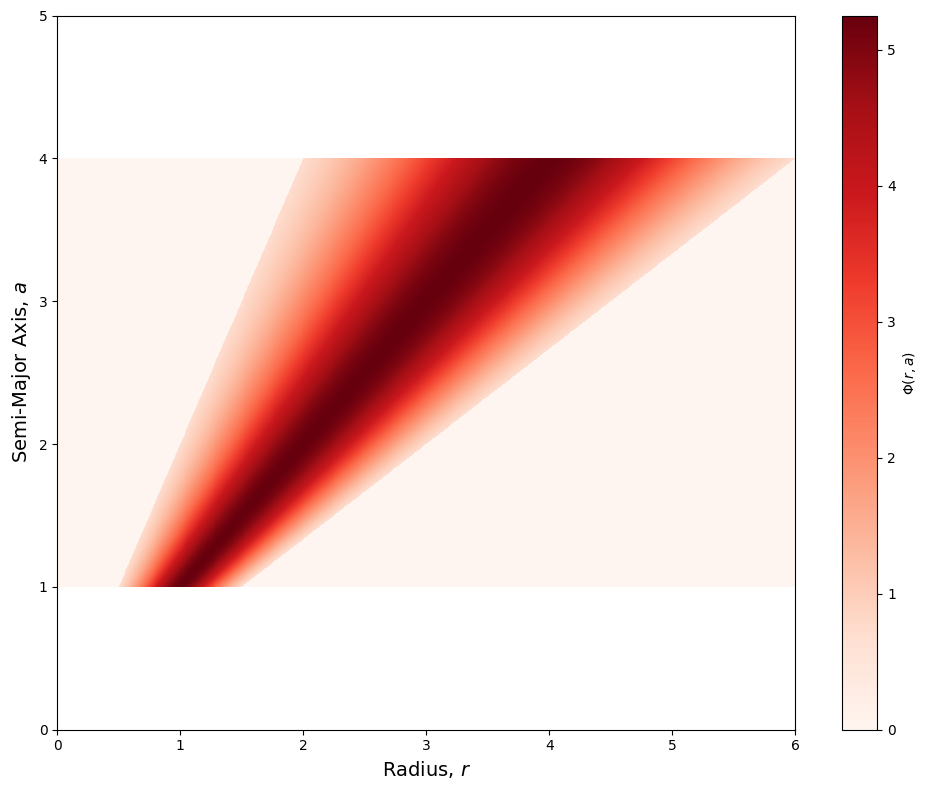

In [16]:
trunc_ecc = TruncGaussEccentricity(a_min=1, a_max=4, lam=0.5, sigma=0.25)

kernel = Kernel(eccentricity_profile=trunc_ecc, 
                r_min = 0.01, r_max = 6,
                num_a_points = 1500, num_r_points = 1500)
kernel.compute()

kernel.plot(cmap = 'Reds', a_lim = (0, 5), r_lim = (0, 6), save = False, shading = 'auto')

#### 1D Slice (Cross-Section) with `plot_slice()`

Plots a 1D slice of $\Phi(r, a)$ by fixing either $a = a_0$ or \(r = r_0\). This is useful to inspect how the kernel varies with radius or semi-major axis.

**Key arguments:**

- `fix_a` or `fix_r`: Choose value and axis to slice
- `log_y`, `log_x`: Plot y- or x-axis in log-scale
- `x_lim`, `y_lim`: Axis range limits
- `save`, `filename`: Same as above

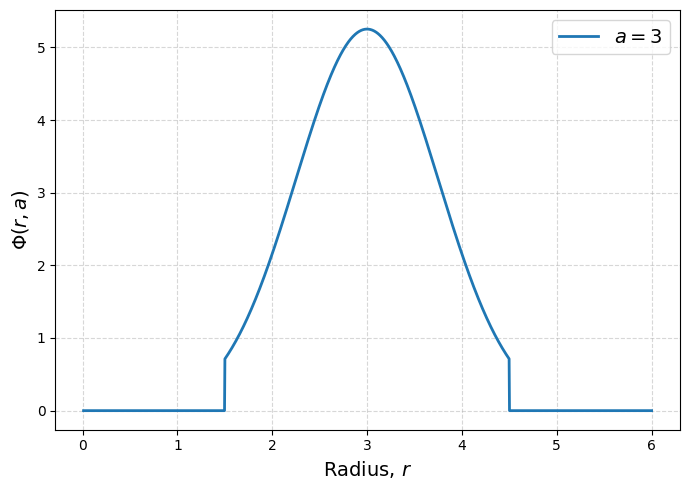

In [17]:
kernel.plot_slice(fix_a = 3)

#### Plotting $\Phi_e(r, a) \; \text{v.s.} \; \kappa(r, a)$ using `plot_phi_kappa()`

Shows the kernel as a function of $\kappa = |1 - r/a|$, which can help visualise the kernel's dependence on geometric separation. Also includes a 1D slice at a chosen $a$-value.

**Key arguments:**

- `cmap`: Colormap for the main heatmap
- `a_slice`: Value of $a$ at which to extract the 1D $\Phi(\kappa)$ slice
- `save`, `filename`: Same as above

> This is currently only available for regular (uniform) gridding.

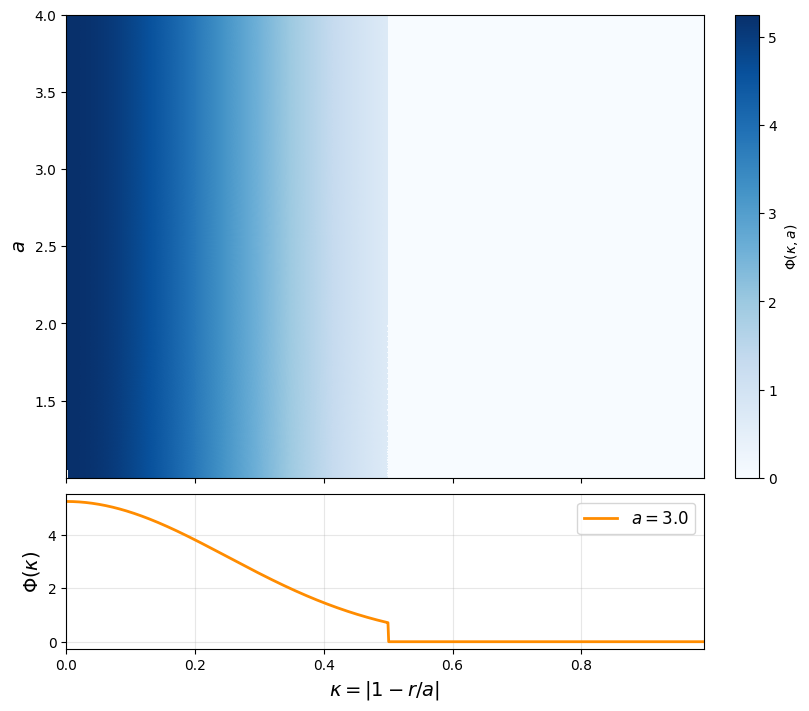

In [18]:
kernel.plot_phi_kappa(cmap = 'Blues', a_slice = 3, save = False)

#### Plot the Kernel Gradient using `plot_grad()`

> This is only available for `UniqueEccentricity` profiles

Visualises the gradient of the kernel after calling `compute_grad()`. The user can select:

- `'norm'`: Full gradient magnitude $|\nabla \Phi|$
- `'da'`: Partial derivative $\partial \Phi / \partial a$
- `'dr'`: Partial derivative $\partial \Phi / \partial r$
- `'all'`: Displays all three side-by-side

**Key arguments:**

- `type`: One of `'norm'`, `'da'`, `'dr'`, or `'all'`
- `vmin`, `vmax`: Colour scale limits
- `a_lim`, `r_lim`: Plot axis limits
- `cmap`, `save`, `filename`: Same as above


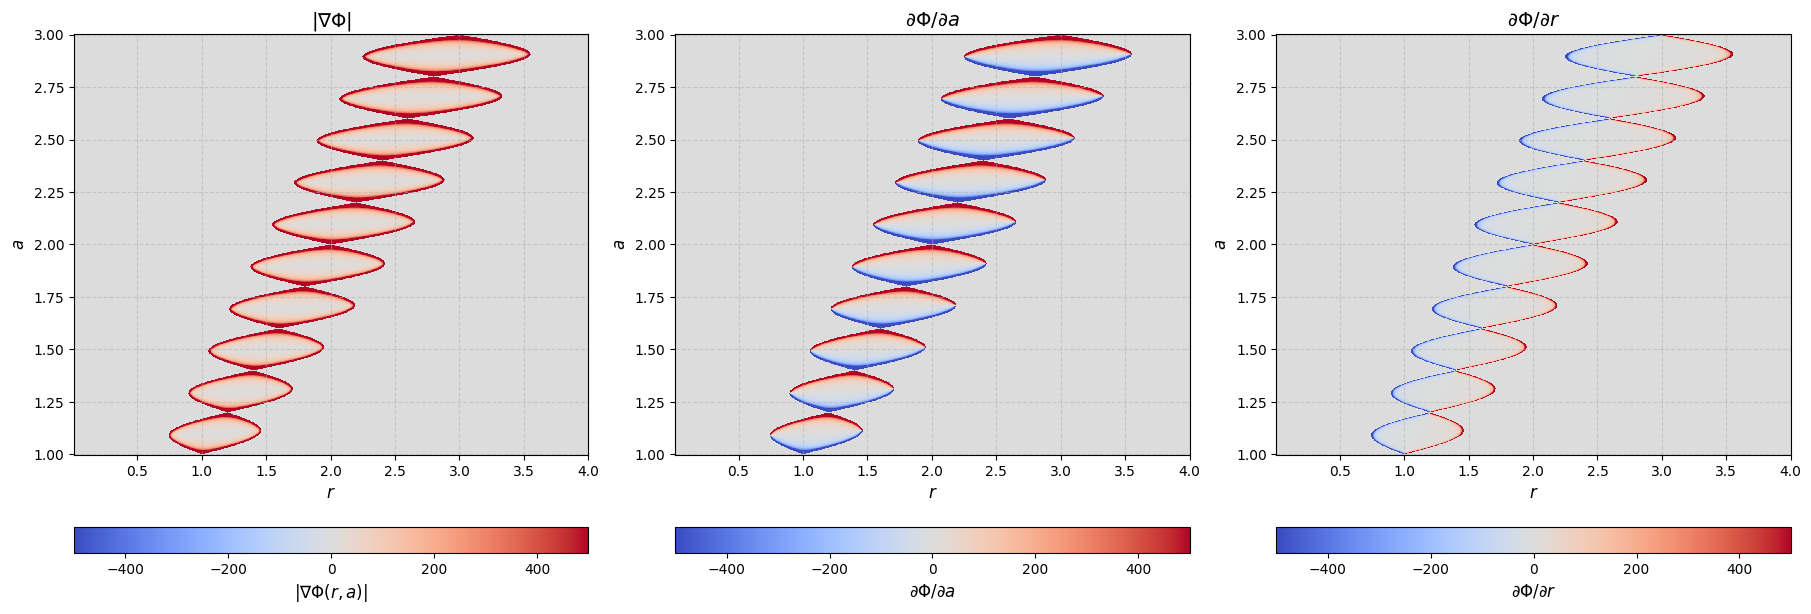

In [19]:
unique_ecc = UniqueEccentricity(a_min=1, a_max=3, eccentricity_func=lambda a: 0.4*np.exp(-a/5)*np.abs(np.sin(a*10*np.pi/2)))

kernel_unique = Kernel(eccentricity_profile=unique_ecc, 
                r_min = 0.01, r_max = 4,
                num_a_points = 1500, num_r_points = 1500)
kernel_unique.compute()
kernel_unique.compute_grad()

kernel_unique.plot_grad(type = 'all', cmap = 'coolwarm', vmin = -500, vmax = 500)